In [84]:
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA


In [85]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [71]:
NUM_POLICY = 5
mode = ["vel",'pos_action','vel_action','pos_vel_action','vel_imu','pos_action_imu','vel_action_imu',
 'pos_vel_action_imu','vel_fc','action_fc','vel_action_fc','pos_vel_action_fc','vel_imu_fc',
 'pos_vel_imu_fc','action_imu_fc','vel_action_imu_fc','pos_vel_action_imu_fc']

flat        =   import_data(mode , NUM_POLICY , case="flat")
slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)
mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]

mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]

In [72]:
flat['pos_vel_action_imu_fc'][0].keys()

dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled'])

## Mutual information between proprioceptive signals

**Is the MI computed correctly?** Yes — the *method* is sound. `mutual_info_regression`
uses the Kraskov–Stögbauer–Grassberger (KSG) k-NN estimator (Ross 2014, for the
continuous–continuous case), a standard non-parametric MI estimator. Three things to
tighten in the original cell:

1. **Sample size (`num_robot`).** With `num_robot = 0` only one robot's 500 timesteps
   feed the estimator; k-NN MI is noisy at *n*=500. Pooling all 30 robots
   (`combine_robots=True`) gives **15,000 samples/joint** and a far more stable estimate.
   Pooling is valid here — every robot samples the *same* joint's (signal-a, signal-b)
   relationship.
2. **i.i.d. assumption.** The samples are consecutive timesteps, so they are temporally
   autocorrelated; KSG assumes i.i.d. draws, which biases MI *upward*. Comparisons
   **between** conditions stay valid (shared bias); read absolute values as optimistic.
3. **The `DataConversionWarning`** is cosmetic — passing `y` as 1-D (`.ravel()`) silences
   it. Scaling is not an issue: KSG is invariant to per-variable monotonic rescaling.

"Sensor condition" here = **which pair of proprioceptive signals** the MI is measured
between, over the fixed full-sensor policy `flat['pos_vel_action_imu_fc']`. The three
per-joint signals give three combinations:
`pos–vel`, `pos–action`, `vel–action`.

In [108]:
# --- Per-joint MI between proprioceptive signals ------------------------------
# KSG k-NN estimator via sklearn (Ross 2014, continuous-continuous case).
# Pool all 30 robots -> 15,000 samples/joint for a stable estimate; pass y as
# 1-D to avoid the DataConversionWarning.
from sklearn.feature_selection import mutual_info_regression

N_JOINTS   = 19
SIGNAL_KEY = {'pos': 'dof_pos', 'vel': 'dof_vel', 'action': 'action'}
PAIRS      = [('pos', 'vel'), ('pos', 'action'), ('vel', 'action')]


def mi_per_joint(entry, sig_a, sig_b, combine_robots=True, random_state=42):
    """Per-joint MI (nats) between two proprioceptive signals of one policy run.

    entry : one dict, e.g. flat['pos_vel_action_imu_fc'][policy_number].
    Returns an array of shape (N_JOINTS,).
    """
    a = entry[SIGNAL_KEY[sig_a]]
    b = entry[SIGNAL_KEY[sig_b]]
    mi = np.empty(N_JOINTS)
    for j in range(N_JOINTS):
        if combine_robots:                       # 500 x 30 = 15,000 samples
            x = a[:, :, j].reshape(-1, 1)
            y = b[:, :, j].ravel()
        else:                                    # single robot, 500 samples
            x = a[:, 0, j].reshape(-1, 1)
            y = b[:, 0, j].ravel()
        mi[j] = mutual_info_regression(x, y, random_state=random_state)[0]
    return mi


# Full-sensor condition, policy 0, all three signal pairs.
POLICY   = 4
entry0   = flat['pos_vel_action_imu_fc'][POLICY]
mi_pairs = {pair: mi_per_joint(entry0, *pair) for pair in PAIRS}

for (sa, sb), mi in mi_pairs.items():
    print(f"{sa:>6}-{sb:<6}  mean MI = {mi.mean():.3f}  (std over joints {mi.std():.3f})")


   pos-vel     mean MI = 0.452  (std over joints 0.199)
   pos-action  mean MI = 0.069  (std over joints 0.057)
   vel-action  mean MI = 0.296  (std over joints 0.179)


### Average MI from each joint

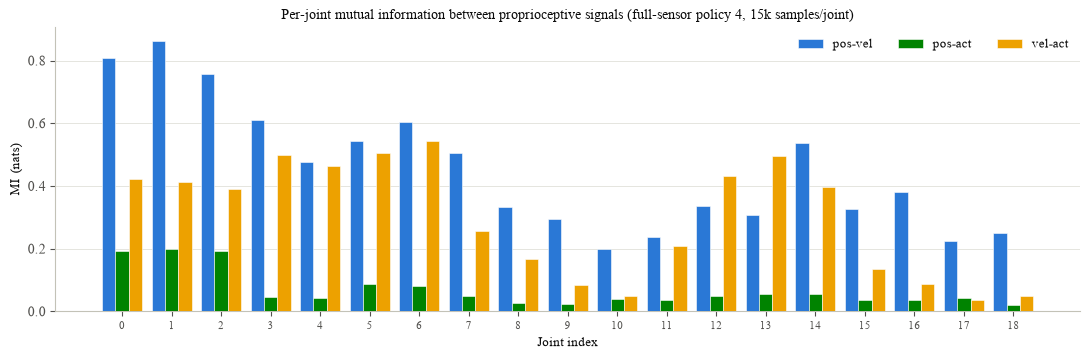

In [109]:
# --- Shared plot style (matches local_prop_p_value2_way.ipynb house style) -----
# Categorical hues reused from that notebook's CVD-validated SERIES palette, one
# fixed hue per signal pair (blue / green / orange are a colour-blind-safe triad).
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e1e0d9'
PAIR_COLOR = {('pos', 'vel'): '#2a78d6', ('pos', 'action'): '#008300',
              ('vel', 'action'): '#eda100'}
PAIR_LABEL = {('pos', 'vel'): 'pos-vel', ('pos', 'action'): 'pos-act',
              ('vel', 'action'): 'vel-act'}

plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.edgecolor': '#c3c2b7', 'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': INK2, 'ytick.color': INK2,
})

# Per-joint MI for policy 0, one grouped bar per signal pair.
x = np.arange(N_JOINTS)
w = 0.27
fig, ax = plt.subplots(figsize=(11, 3.7))

for i, pair in enumerate(PAIRS):
    ax.bar(x + (i - 1) * w, mi_pairs[pair], width=w, color=PAIR_COLOR[pair],
           label=PAIR_LABEL[pair], edgecolor='white', linewidth=0.4, zorder=3)

ax.set_xticks(x); ax.set_xticklabels(x, fontsize=8)
ax.set_xlabel('Joint index', fontsize=9.5)
ax.set_ylabel('MI  (nats)', fontsize=9.5)
ax.set_title(f"Per-joint mutual information between proprioceptive signals "
             f"(full-sensor policy {POLICY}, 15k samples/joint)", fontsize=10)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9, loc='upper right')
fig.tight_layout()
plt.show()


### Compare MI across sensor conditions

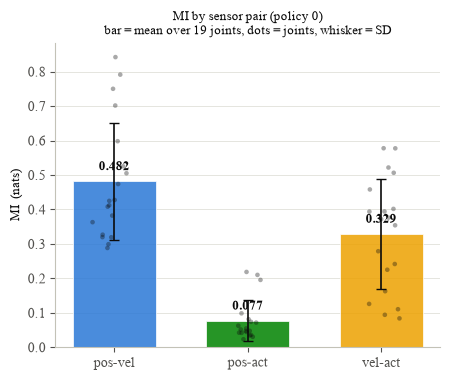

In [76]:
# Compare the three sensor conditions (signal pairs) for policy 0: mean MI over
# the 19 joints, with each joint shown as a dot and SD as a whisker.
fig, ax = plt.subplots(figsize=(4.6, 3.9))
rng = np.random.default_rng(0)

for i, pair in enumerate(PAIRS):
    vals = mi_pairs[pair]                             # (19 joints,)
    ax.bar(i, vals.mean(), width=0.62, color=PAIR_COLOR[pair], alpha=0.85,
           edgecolor='white', linewidth=0.6, zorder=2)
    ax.scatter(rng.normal(i, 0.07, vals.size), vals, s=11, color=INK, alpha=0.35,
               edgecolors='none', zorder=4)
    ax.errorbar(i, vals.mean(), yerr=vals.std(), fmt='none', ecolor=INK,
                lw=1.2, capsize=3.5, zorder=5)
    ax.annotate(f"{vals.mean():.3f}", (i, vals.mean()), xytext=(0, 6),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(range(len(PAIRS)))
ax.set_xticklabels([PAIR_LABEL[p] for p in PAIRS], fontsize=10)
ax.set_ylabel('MI  (nats)', fontsize=9.5)
ax.set_title(f"MI by sensor pair (policy {POLICY})\n"
             "bar = mean over 19 joints, dots = joints, whisker = SD", fontsize=9.5)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()


### Across policy numbers

Repeat the estimate for every `flat['pos_vel_action_imu_fc'][num_pol]` and re-plot, so
each bar is an average over the 5 policy instances instead of a single run.

In [77]:
# Recompute across every policy number of the full-sensor condition.
# mi_by_policy[pair] has shape (NUM_POLICY, N_JOINTS).  (~20 s: 3 pairs x 5
# policies x 19 joints, 15k samples each.)
mi_by_policy = {
    pair: np.stack([mi_per_joint(flat['pos_vel_action_imu_fc'][p], *pair)
                    for p in range(NUM_POLICY)])
    for pair in PAIRS
}

for (sa, sb), m in mi_by_policy.items():
    per_pol = m.mean(1)                                # mean over joints, per policy
    print(f"{sa:>6}-{sb:<6}  per-policy mean MI = "
          f"[{', '.join(f'{v:.3f}' for v in per_pol)}]  "
          f"overall {m.mean():.3f}")


   pos-vel     per-policy mean MI = [0.482, 0.483, 0.428, 0.489, 0.452]  overall 0.467
   pos-action  per-policy mean MI = [0.077, 0.075, 0.080, 0.066, 0.069]  overall 0.074
   vel-action  per-policy mean MI = [0.329, 0.319, 0.310, 0.315, 0.296]  overall 0.314


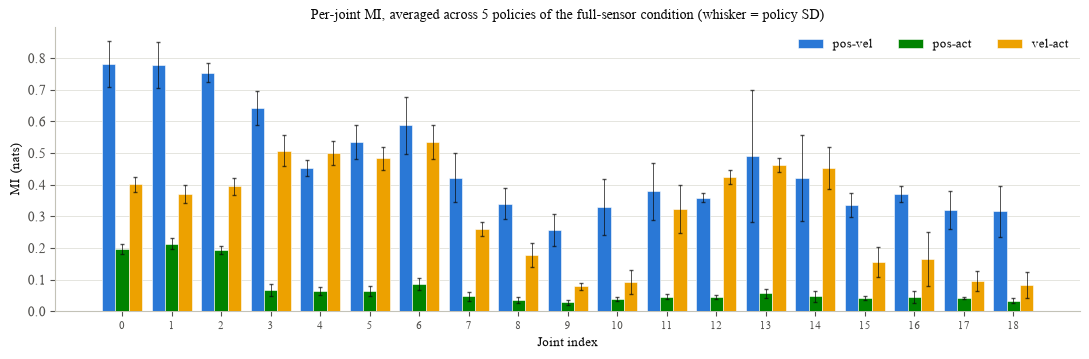

In [110]:
# Per-joint MI averaged over the 5 policies (whisker = spread across policies).
# This is the robust version of the first bar chart: each bar is a mean of 5
# independent policy estimates rather than a single run.
x = np.arange(N_JOINTS)
w = 0.27
fig, ax = plt.subplots(figsize=(11, 3.7))

for i, pair in enumerate(PAIRS):
    m = mi_by_policy[pair]                             # (5 policies, 19 joints)
    ax.bar(x + (i - 1) * w, m.mean(0), width=w, color=PAIR_COLOR[pair],
           label=PAIR_LABEL[pair], edgecolor='white', linewidth=0.4, zorder=3)
    ax.errorbar(x + (i - 1) * w, m.mean(0), yerr=m.std(0), fmt='none',
                ecolor=INK, elinewidth=0.7, capsize=1.5, alpha=0.7, zorder=4)

ax.set_xticks(x); ax.set_xticklabels(x, fontsize=8)
ax.set_xlabel('Joint index', fontsize=9.5)
ax.set_ylabel('MI  (nats)', fontsize=9.5)
ax.set_title("Per-joint MI, averaged across 5 policies of the full-sensor condition "
             "(whisker = policy SD)", fontsize=10)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig("local_prop_MI_all_pol.png", dpi=300, bbox_inches="tight")
plt.show()


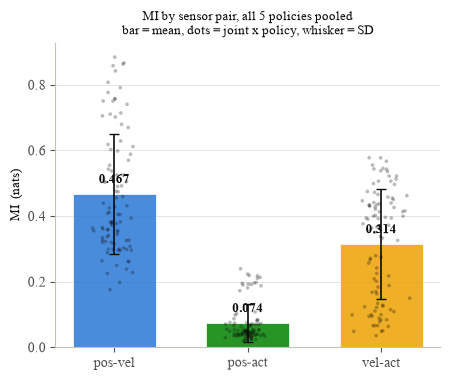

In [79]:
# Sensor-condition comparison, pooling every joint of every policy (5 x 19 = 95
# points per pair) -> the headline "which signal pair shares most information".
fig, ax = plt.subplots(figsize=(4.6, 3.9))
rng = np.random.default_rng(0)

for i, pair in enumerate(PAIRS):
    vals = mi_by_policy[pair].ravel()                 # (5 policies x 19 joints,)
    ax.bar(i, vals.mean(), width=0.62, color=PAIR_COLOR[pair], alpha=0.85,
           edgecolor='white', linewidth=0.6, zorder=2)
    ax.scatter(rng.normal(i, 0.07, vals.size), vals, s=7, color=INK, alpha=0.28,
               edgecolors='none', zorder=4)
    ax.errorbar(i, vals.mean(), yerr=vals.std(), fmt='none', ecolor=INK,
                lw=1.2, capsize=3.5, zorder=5)
    ax.annotate(f"{vals.mean():.3f}", (i, vals.mean()), xytext=(0, 6),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(range(len(PAIRS)))
ax.set_xticklabels([PAIR_LABEL[p] for p in PAIRS], fontsize=10)
ax.set_ylabel('MI  (nats)', fontsize=9.5)
ax.set_title("MI by sensor pair, all 5 policies pooled\n"
             "bar = mean, dots = joint x policy, whisker = SD", fontsize=9.5)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()


### Mean MI per sensor pair, and per policy

Collapse the joint dimension entirely: one number per sensor condition (the mean MI over
all joints), and how that mean moves across the 5 policy instances.

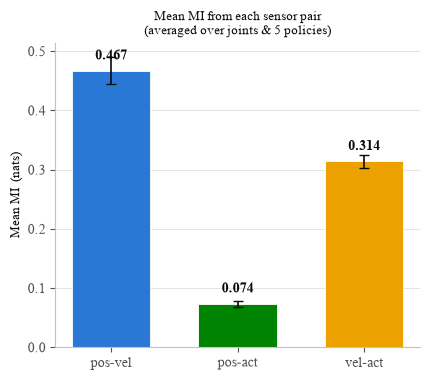

In [80]:
# Mean MI from each sensor pair — a single bar per condition, averaged over all
# joints and all 5 policies (whisker = SD across the 5 policy means).
fig, ax = plt.subplots(figsize=(4.4, 3.9))

for i, pair in enumerate(PAIRS):
    per_pol = mi_by_policy[pair].mean(1)              # (5,) joint-mean per policy
    ax.bar(i, per_pol.mean(), width=0.62, color=PAIR_COLOR[pair],
           edgecolor='white', linewidth=0.6, zorder=2)
    ax.errorbar(i, per_pol.mean(), yerr=per_pol.std(), fmt='none', ecolor=INK,
                lw=1.2, capsize=3.5, zorder=4)
    ax.annotate(f"{per_pol.mean():.3f}", (i, per_pol.mean()), xytext=(0, 6),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_xticks(range(len(PAIRS)))
ax.set_xticklabels([PAIR_LABEL[p] for p in PAIRS], fontsize=10)
ax.set_ylabel('Mean MI  (nats)', fontsize=9.5)
ax.set_title("Mean MI from each sensor pair\n(averaged over joints & 5 policies)",
             fontsize=9.5)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()


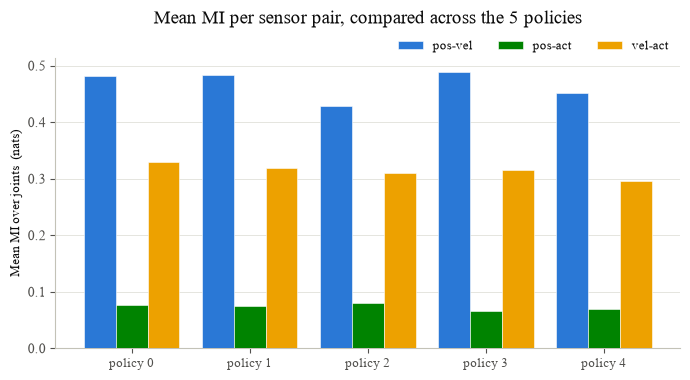

In [111]:
# Compare the 5 policies: x = policy number, grouped bar per sensor pair, height
# = mean MI over the 19 joints for that policy.
x = np.arange(NUM_POLICY)
w = 0.27
fig, ax = plt.subplots(figsize=(7, 3.9))

for i, pair in enumerate(PAIRS):
    means = mi_by_policy[pair].mean(1)                # (5,) joint-mean per policy
    ax.bar(x + (i - 1) * w, means, width=w, color=PAIR_COLOR[pair],
           label=PAIR_LABEL[pair], edgecolor='white', linewidth=0.4, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"policy {p}" for p in range(NUM_POLICY)], fontsize=9)
ax.set_ylabel('Mean MI over joints  (nats)', fontsize=9.5)
ax.set_title("Mean MI per sensor pair, compared across the 5 policies", fontsize=14, pad=25)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9, loc='upper right',
          bbox_to_anchor=(1.0, 1.1))
fig.tight_layout()
fig.savefig("local_prop_MI_mean-joint_all_pol.png", dpi=300, bbox_inches="tight")
plt.show()


### Time-series of the sensor feedback (pos, vel, action)

The raw signals over time explain the MI numbers. Because the three live on different
scales (rad, rad/s, normalized), they get **one panel each** (honest magnitudes) rather
than a shared axis. The standardized (z-scored) overlay below then shows the coupling
directly: `pos` and `vel` co-move with a derivative phase shift — the high pos–vel MI —
while `action` saturates and tracks `pos` weakly — the low pos–action MI.

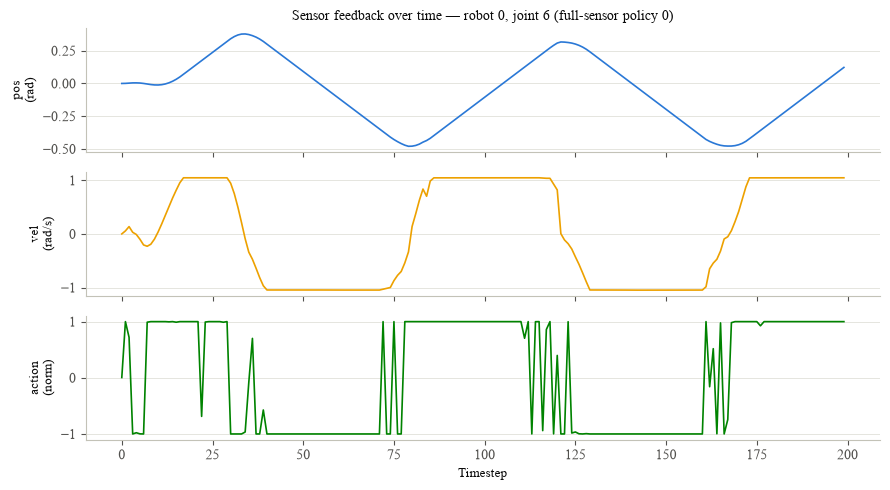

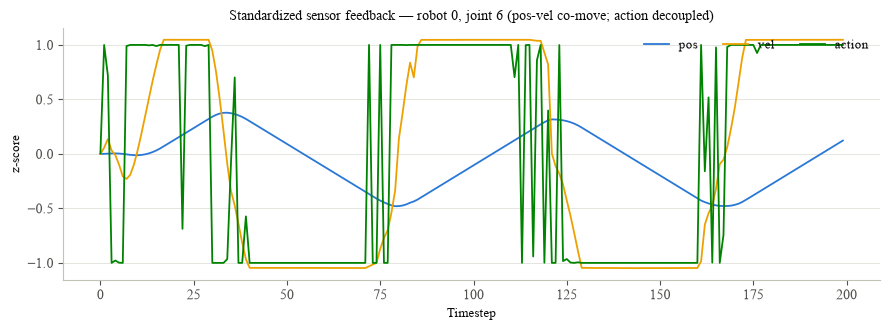

In [82]:
# Raw signals, one panel per sensor (own y-scale), shared time axis.
SIGNAL_COLOR = {'pos': '#2a78d6', 'vel': '#eda100', 'action': '#008300'}
SIGNAL_UNIT  = {'pos': 'rad', 'vel': 'rad/s', 'action': 'norm'}
SIGNALS      = ['pos', 'vel', 'action']

ROBOT, JOINT = 0, 6                                  
# change to inspect others
T = slice(0, 200)                                     # window of timesteps shown
entry = flat['pos_vel_action_imu_fc'][POLICY]
t = np.arange(*T.indices(entry['action'].shape[0]))

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(9, 5), sharex=True)
for ax, sig in zip(axes, SIGNALS):
    y = entry[SIGNAL_KEY[sig]][T, ROBOT, JOINT]
    ax.plot(t, y, color=SIGNAL_COLOR[sig], lw=1.2, zorder=3)
    ax.set_ylabel(f"{sig}\n({SIGNAL_UNIT[sig]})", fontsize=9)
    ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[-1].set_xlabel('Timestep', fontsize=9.5)
axes[0].set_title(f"Sensor feedback over time — robot {ROBOT}, joint {JOINT} "
                  f"(full-sensor policy {POLICY})", fontsize=10)
fig.tight_layout()
plt.show()

##################

# Standardized overlay (z-score per signal) — same robot/joint/window as above.
# Shared axis is honest here because every trace is unit-variance; this is the
# coupling view, not a magnitude comparison.
fig, ax = plt.subplots(figsize=(9, 3.4))
for sig in SIGNALS:
    y = entry[SIGNAL_KEY[sig]][T, ROBOT, JOINT]
    ax.plot(t, y, color=SIGNAL_COLOR[sig], lw=1.3, label=sig, zorder=3)

ax.set_xlabel('Timestep', fontsize=9.5)
ax.set_ylabel('z-score', fontsize=9.5)
ax.set_title(f"Standardized sensor feedback — robot {ROBOT}, joint {JOINT} "
             f"(pos-vel co-move; action decoupled)", fontsize=10)
ax.grid(True, axis='y', color=GRID, lw=0.6); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9, loc='upper right')
fig.tight_layout()
plt.show()



### Per-joint sensor feedback from the observation vector

One subplot per joint, each overlaying the three feedback channels the policy actually
receives, sliced straight out of the 64-d `state` observation:

| channel | `state` columns | verified against |
|---|---|---|
| joint position | `0:19`   | `dof_pos_scaled` (corr 0.998) |
| joint velocity | `19:38`  | `dof_vel` (corr 0.989) |
| action feedback | `38:57` | previous-step `action` (corr 1.000) |

The remaining columns `57:64` are the IMU / gravity / command terms. All three channels
are already in observation (normalized) units, so they share one axis honestly. `action`
is drawn behind so the smoother pos/vel traces stay visible on the bang-bang joints.

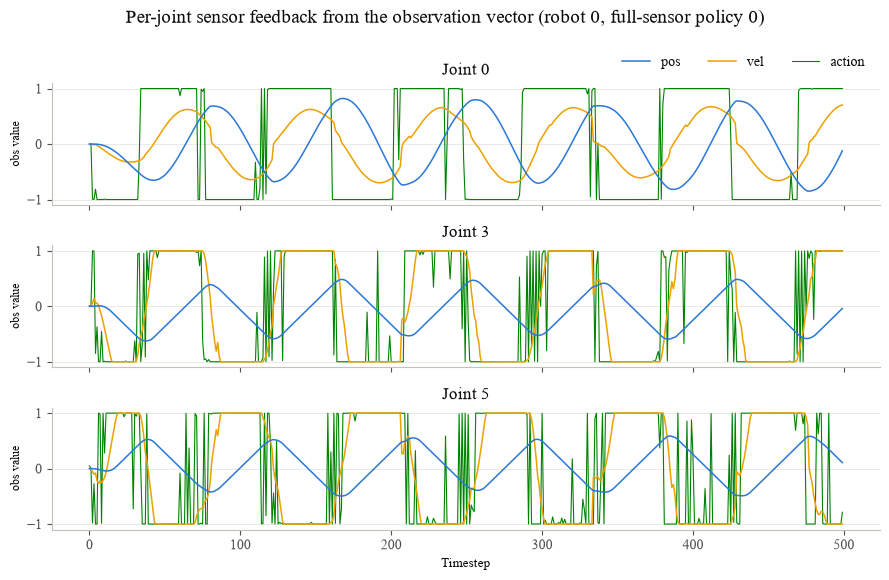

In [83]:
# Per-joint feedback pulled from the state observation. Each channel is a 19-wide
# block, so joint j of channel `sig` is column STATE_OFF[sig] + j.
STATE_OFF    = {'pos': 0, 'vel': 19, 'action': 38}    # verified above
STATE_ZORDER = {'action': 2, 'vel': 3, 'pos': 4}      # action behind pos/vel
STATE_LW     = {'action': 0.8, 'vel': 1.1, 'pos': 1.1}

JOINTS = [0, 3, 5]                                   # <-- pick the joints to show
ROBOT  = 0                                            # change to inspect others
T = slice(0, 500)                                     # window of timesteps shown
state = flat['pos_vel_action_imu_fc'][POLICY]['state']
t = np.arange(*T.indices(state.shape[0]))

fig, axes = plt.subplots(len(JOINTS), 1, figsize=(9, 1.9 * len(JOINTS)),
                         sharex=True, squeeze=False)
axes = axes.ravel()

for ax, j in zip(axes, JOINTS):
    for sig in SIGNALS:                              # ['pos', 'vel', 'action']
        y = state[T, ROBOT, STATE_OFF[sig] + j]
        ax.plot(t, y, color=SIGNAL_COLOR[sig], lw=STATE_LW[sig],
                zorder=STATE_ZORDER[sig], label=sig if j == JOINTS[0] else None)
    ax.set_title(f"Joint {j}", fontsize=12, loc='center')
    ax.set_ylabel('obs value', fontsize=8.5)
    ax.grid(True, axis='y', color=GRID, lw=0.5); ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[-1].set_xlabel('Timestep', fontsize=9.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=False, ncol=3, fontsize=10,
           bbox_to_anchor=(0.98, 0.95))
fig.suptitle(f"Per-joint sensor feedback from the observation vector "
             f"(robot {ROBOT}, full-sensor policy {POLICY})", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()
